In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_TOPN, METHOD_PPO, METHOD_DQN

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-09 08:36:59.574 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [10]:
max_peaks = 200
in_dir = 'results'

In [11]:
n_eval_episodes = 5
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [12]:
set_log_level_warning()

1

In [13]:
eval_dir = 'evaluation'
methods = [
    METHOD_PPO,
    METHOD_TOPN,
    METHOD_RANDOM,
]

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4


#### Run different methods

In [15]:
for chems in chem_list:
    print(len(chems))

11879
15240
12921
12024
12413


In [16]:
max_peaks

200

In [17]:
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation')

#### Compare to Top-10

In [18]:
env_name = 'DDAEnv'
model_name = 'PPO'
intensity_threshold = 0.5

In [19]:
method_eval_results = {}
for method in methods:

    if method in (METHOD_PPO, METHOD_DQN):
        effective_rt_tol = rt_tol
    else:
        effective_rt_tol = exclusion_t_0        
    copy_params = dict(params)        
    copy_params['env']['rt_tol'] = effective_rt_tol
    
    banner = 'method = %s max_peaks = %d rt_tol = %d' % (method, max_peaks, effective_rt_tol)
    print(banner)
    print()

    if method == METHOD_PPO:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = PPO.load(fname)
    elif method == METHOD_DQN:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = DQN.load(fname)
    else:
        model = None

    episodic_results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, 
                                  N=N, min_ms1_intensity=min_ms1_intensity, model=model,
                                  print_eval=True, print_reward=False, intensity_threshold=intensity_threshold)
    eval_results = [er.eval_res for er in episodic_results]
    method_eval_results[method] = eval_results
    print()

method = PPO max_peaks = 200 rt_tol = 120

{'coverage_prop': '0.359', 'intensity_prop': '0.251', 'ms1/ms2 ratio': '0.324', 'efficiency': '0.977', 'TP': '2289', 'FP': '488', 'FN': '9102', 'precision': '0.824', 'recall': '0.201', 'f1': '0.323'}
{'coverage_prop': '0.315', 'intensity_prop': '0.219', 'ms1/ms2 ratio': '0.302', 'efficiency': '1.068', 'TP': '2209', 'FP': '493', 'FN': '12538', 'precision': '0.818', 'recall': '0.150', 'f1': '0.253'}
{'coverage_prop': '0.347', 'intensity_prop': '0.243', 'ms1/ms2 ratio': '0.324', 'efficiency': '1.027', 'TP': '2295', 'FP': '475', 'FN': '10151', 'precision': '0.829', 'recall': '0.184', 'f1': '0.302'}
{'coverage_prop': '0.362', 'intensity_prop': '0.252', 'ms1/ms2 ratio': '0.320', 'efficiency': '0.993', 'TP': '2247', 'FP': '521', 'FN': '9256', 'precision': '0.812', 'recall': '0.195', 'f1': '0.315'}
{'coverage_prop': '0.351', 'intensity_prop': '0.244', 'ms1/ms2 ratio': '0.319', 'efficiency': '0.990', 'TP': '2180', 'FP': '534', 'FN': '9699', 'precision'

#### Test classic controllers in ViMMS

In [20]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [21]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

effective_rt_tol = rt_tol
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, N, isolation_window, mz_tol, effective_rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.378', 'intensity_prop': '0.262', 'ms1/ms2 ratio': '0.265', 'efficiency': '0.953', 'TP': '2353', 'FP': '571', 'FN': '8955', 'precision': '0.805', 'recall': '0.208', 'f1': '0.331'}
Episode 1 finished
{'coverage_prop': '0.332', 'intensity_prop': '0.231', 'ms1/ms2 ratio': '0.211', 'efficiency': '1.000', 'TP': '2306', 'FP': '538', 'FN': '12396', 'precision': '0.811', 'recall': '0.157', 'f1': '0.263'}
Episode 2 finished
{'coverage_prop': '0.359', 'intensity_prop': '0.250', 'ms1/ms2 ratio': '0.246', 'efficiency': '0.960', 'TP': '2353', 'FP': '557', 'FN': '10011', 'precision': '0.809', 'recall': '0.190', 'f1': '0.308'}
Episode 3 finished
{'coverage_prop': '0.376', 'intensity_prop': '0.263', 'ms1/ms2 ratio': '0.270', 'efficiency': '0.968', 'TP': '2357', 'FP': '567', 'FN': '9100', 'precision': '0.806', 'recall': '0.206', 'f1': '0.328'}
Episode 4 finished
{'coverage_prop': '0.366', 'intensity_prop': '0.256', 'ms1/ms2 ratio': '0.256

Run SmartROI Controller

In [22]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

effective_rt_tol = exclusion_t_0
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams()
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, N, mz_tol, effective_rt_tol,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.254', 'intensity_prop': '0.169', 'ms1/ms2 ratio': '0.951', 'efficiency': '1.218', 'TP': '1298', 'FP': '457', 'FN': '10124', 'precision': '0.740', 'recall': '0.114', 'f1': '0.197'}
Episode 1 finished
{'coverage_prop': '0.244', 'intensity_prop': '0.162', 'ms1/ms2 ratio': '0.793', 'efficiency': '1.336', 'TP': '1366', 'FP': '509', 'FN': '13365', 'precision': '0.729', 'recall': '0.093', 'f1': '0.165'}
Episode 2 finished
{'coverage_prop': '0.242', 'intensity_prop': '0.161', 'ms1/ms2 ratio': '0.899', 'efficiency': '1.217', 'TP': '1313', 'FP': '476', 'FN': '11132', 'precision': '0.734', 'recall': '0.106', 'f1': '0.184'}
Episode 3 finished
{'coverage_prop': '0.250', 'intensity_prop': '0.166', 'ms1/ms2 ratio': '0.971', 'efficiency': '1.227', 'TP': '1269', 'FP': '453', 'FN': '10302', 'precision': '0.737', 'recall': '0.110', 'f1': '0.191'}
Episode 4 finished
{'coverage_prop': '0.249', 'intensity_prop': '0.165', 'ms1/ms2 ratio': 

Run WeightedDEW Controller

In [23]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, N, isolation_window, mz_tol, rt_tol,
                                min_ms1_intensity, exclusion_t_0=exclusion_t_0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.360', 'intensity_prop': '0.253', 'ms1/ms2 ratio': '0.178', 'efficiency': '0.805', 'TP': '2219', 'FP': '479', 'FN': '9181', 'precision': '0.822', 'recall': '0.195', 'f1': '0.315'}
Episode 1 finished
{'coverage_prop': '0.317', 'intensity_prop': '0.222', 'ms1/ms2 ratio': '0.156', 'efficiency': '0.882', 'TP': '2188', 'FP': '456', 'FN': '12596', 'precision': '0.828', 'recall': '0.148', 'f1': '0.251'}
Episode 2 finished
{'coverage_prop': '0.342', 'intensity_prop': '0.241', 'ms1/ms2 ratio': '0.167', 'efficiency': '0.819', 'TP': '2258', 'FP': '441', 'FN': '10222', 'precision': '0.837', 'recall': '0.181', 'f1': '0.298'}
Episode 3 finished
{'coverage_prop': '0.357', 'intensity_prop': '0.251', 'ms1/ms2 ratio': '0.193', 'efficiency': '0.825', 'TP': '2248', 'FP': '474', 'FN': '9302', 'precision': '0.826', 'recall': '0.195', 'f1': '0.315'}
Episode 4 finished
{'coverage_prop': '0.347', 'intensity_prop': '0.244', 'ms1/ms2 ratio':

#### Plotting

Flatten data into dataframe

In [24]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (
            method, 
            float(eval_res['coverage_prop']), 
            float(eval_res['intensity_prop']), 
            float(eval_res['ms1/ms2 ratio']), 
            float(eval_res['efficiency']),
            float(eval_res['precision']),
            float(eval_res['recall']),
            float(eval_res['f1']),            
        )
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency', 'precision', 'recall', 'f1'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency,precision,recall,f1
0,PPO,0.359,0.251,0.324,0.977,0.824,0.201,0.323
1,PPO,0.315,0.219,0.302,1.068,0.818,0.150,0.253
2,PPO,0.347,0.243,0.324,1.027,0.829,0.184,0.302
3,PPO,0.362,0.252,0.320,0.993,0.812,0.195,0.315
4,PPO,0.351,0.244,0.319,0.990,0.803,0.184,0.299


In [25]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

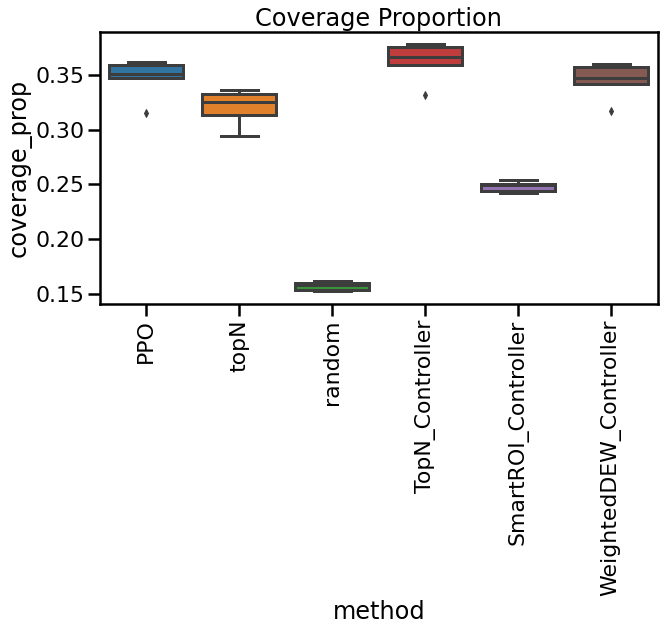

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

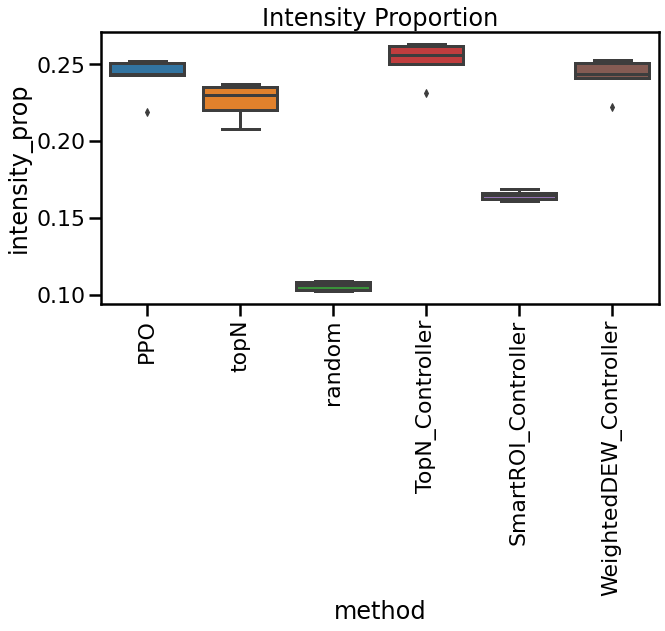

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

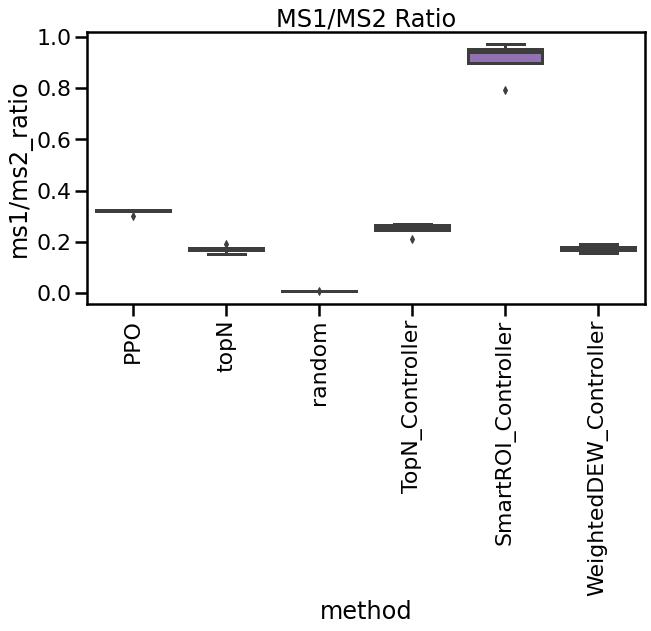

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

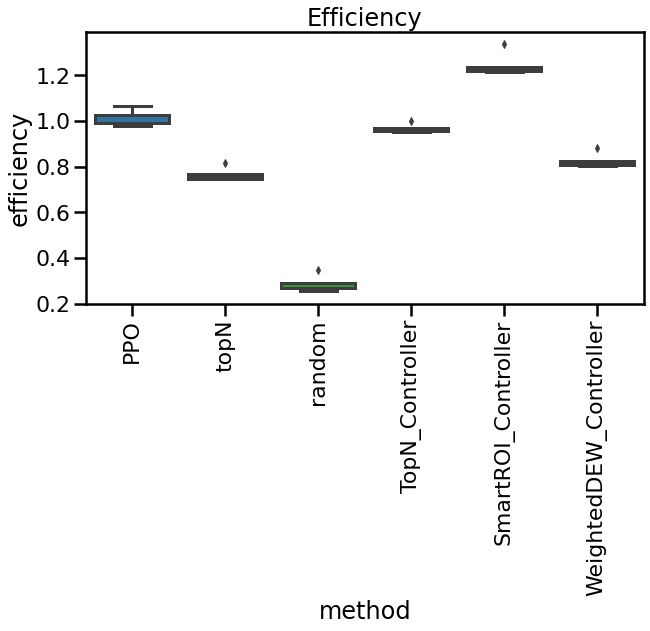

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')

Text(0.5, 1.0, 'Precision')

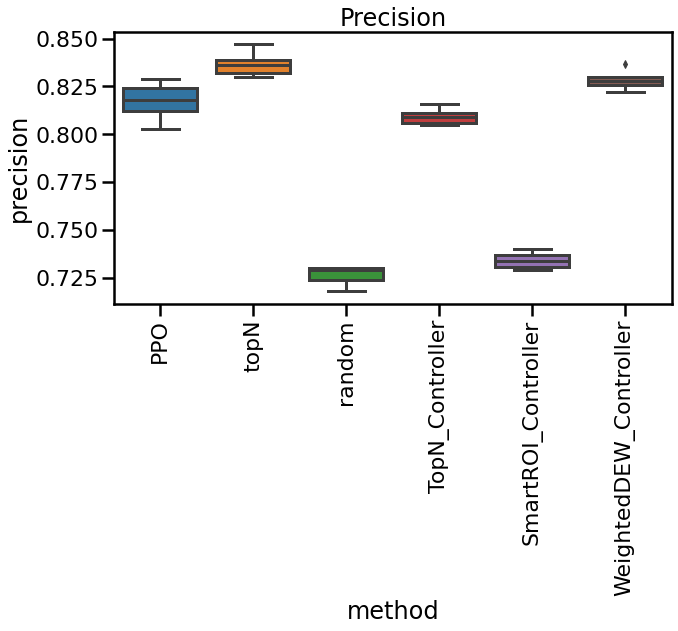

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='precision')
plt.xticks(rotation=90)
plt.title('Precision')

Text(0.5, 1.0, 'Recall')

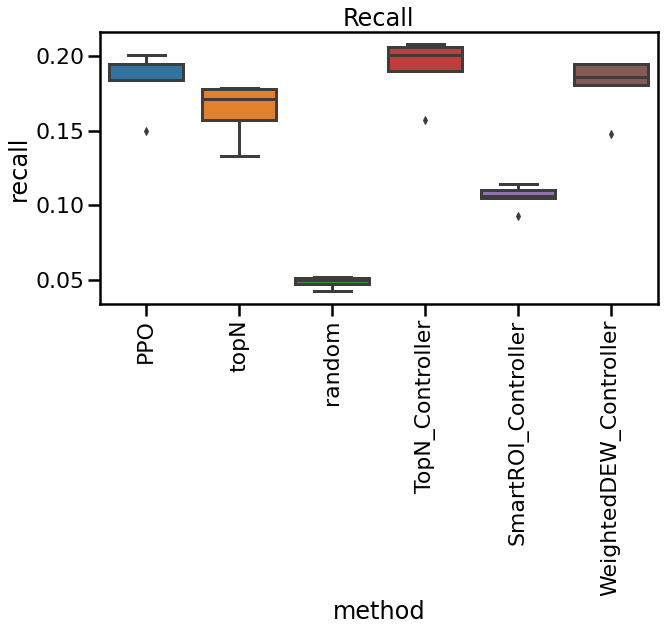

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='recall')
plt.xticks(rotation=90)
plt.title('Recall')

Text(0.5, 1.0, 'F1')

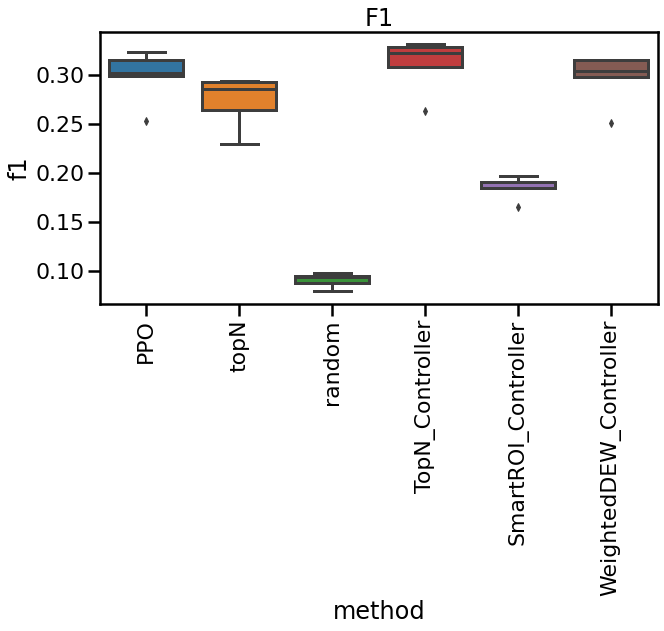

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='f1')
plt.xticks(rotation=90)
plt.title('F1')